# Data exploration with smaller file GDSC2_fitted_dose_response_27Oct23.xlsx

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import time
import re

## Read in drug data

In [2]:
df = pd.read_excel(r'C:\Users\Juli\Downloads\GDSC2_fitted_dose_response_27Oct23.xlsx')

In [3]:
df.head()

,DATASET,NLME_RESULT_ID,NLME_CURVE_ID,CELL_LINE_NAME,SANGER_MODEL_ID,CANCER_TYPE,DRUG_ID,DRUG_NAME,PUTATIVE_TARGET,PATHWAY_NAME,MIN_CONC,MAX_CONC,LN_IC50,AUC,RMSE,Z_SCORE
0,GDSC2,343,15946310,PFSK-1,SIDM01132,Other Solid Cancers,1003,Camptothecin,TOP1,DNA replication,0.0001,0.1,-1.463887,0.930220,0.089052,0.433123
1,GDSC2,343,15946548,A673,SIDM00848,Ewing's Sarcoma,1003,Camptothecin,TOP1,DNA replication,0.0001,0.1,-4.869455,0.614970,0.111351,-1.421100
2,GDSC2,343,15946830,ES5,SIDM00263,Ewing's Sarcoma,1003,Camptothecin,TOP1,DNA replication,0.0001,0.1,-3.360586,0.791072,0.142855,-0.599569
3,GDSC2,343,15947087,ES7,SIDM00269,Ewing's Sarcoma,1003,Camptothecin,TOP1,DNA replication,0.0001,0.1,-5.044940,0.592660,0.135539,-1.516647
4,GDSC2,343,15947369,EW-11,SIDM00203,Ewing's Sarcoma,1003,Camptothecin,TOP1,DNA replication,0.0001,0.1,-3.741991,0.734047,0.128059,-0.807232


## Data Dictionary


| Field Name | Description |
|---|---|
| DATASET | Indicates the dataset name. Datasets are processed as a whole. |
| NLME_RESULT_ID | Identifier for the fitted results. (Nonlinear mixed effect models)|
| NLME_CURVE_ID | Identifier for the fitted dose response. |
| CELL_LINE_NAME | Model name. |
| SANGER_MODEL_ID | Sanger DepMap model identifier. |
| CANCER_TYPE | Sanger DepMap cancer type annotation. |
| DRUG_ID | Drug identifier. |
| DRUG_NAME | Primary drug name. |
| PUTATIVE_TARGET | Putative drug target. |
| PATHWAY_NAME | Pathway assigned to the putative drug target. |
| MIN_CONC | Minimum micromolar screening concentration of the drug within the dataset. |
| MAX_CONC | Maximum micromolar screening concentration of the drug within the dataset. |
| LN_IC50 | Natural log of the fitted IC50. |
| AUC | Area Under the Curve for the fitted model. Presented as a fraction of the total area between the highest and lowest screening concentration. -> Je kleiner die Fläche, desto stärker wirkt das Medikament. proxy for accuracy of IC50|
| RMSE | Root Mean Squared Error, a measurement of how well the modelled curve fits the data points. Curves with RMSE > 0.3 are excluded prior to release as part of quality control. |
| Z_SCORE | Z score of the LN_IC50 comparing it to the mean and standard deviation of the LN_IC50 values for the drug in question over all models treated. suitable measurement value for our drug screening response matrix as it corresponds to a normalization for each drug over all cell lines|

## Get to know the data

In [5]:
#print(df.groupby('CANCER_TYPE').CANCER_TYPE.value_counts())
print(df.groupby('DRUG_NAME').DRUG_NAME.value_counts())

DRUG_NAME
123138                   717
123829                   717
150412                   717
5-Fluorouracil           968
5-azacytidine            740
                        ... 
ZM447439                 944
Zoledronate              717
alpha-lipoic acid        735
ascorbate (vitamin C)    732
glutathione              732
Name: count, Length: 286, dtype: int64


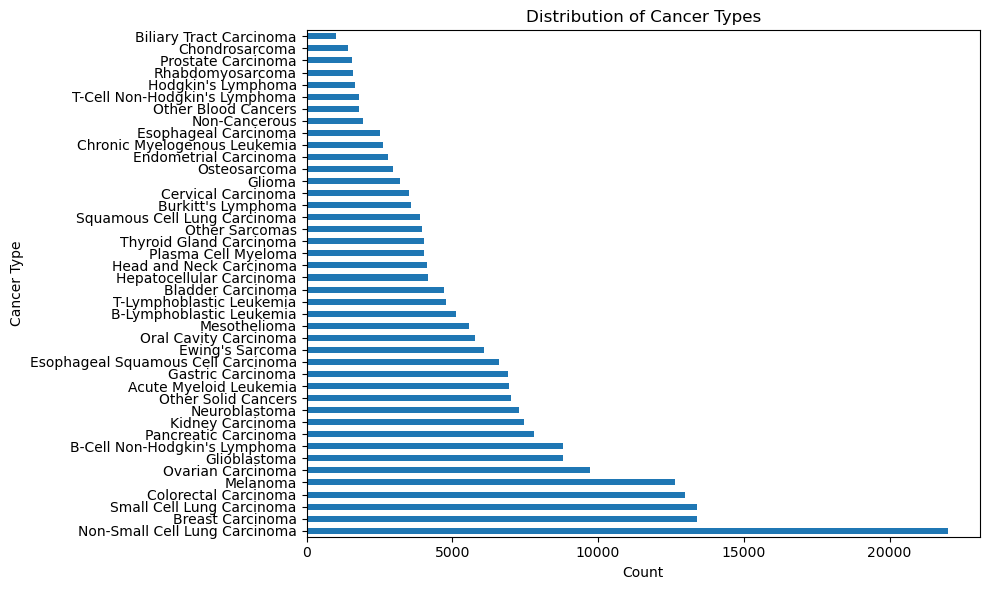

In [6]:
df_cancer_type_counts = df['CANCER_TYPE'].value_counts()
plt.figure(figsize=(10, 6))
df_cancer_type_counts.plot(kind='barh')
plt.xlabel('Count')
plt.ylabel('Cancer Type')
plt.title('Distribution of Cancer Types')
plt.tight_layout()
plt.show()

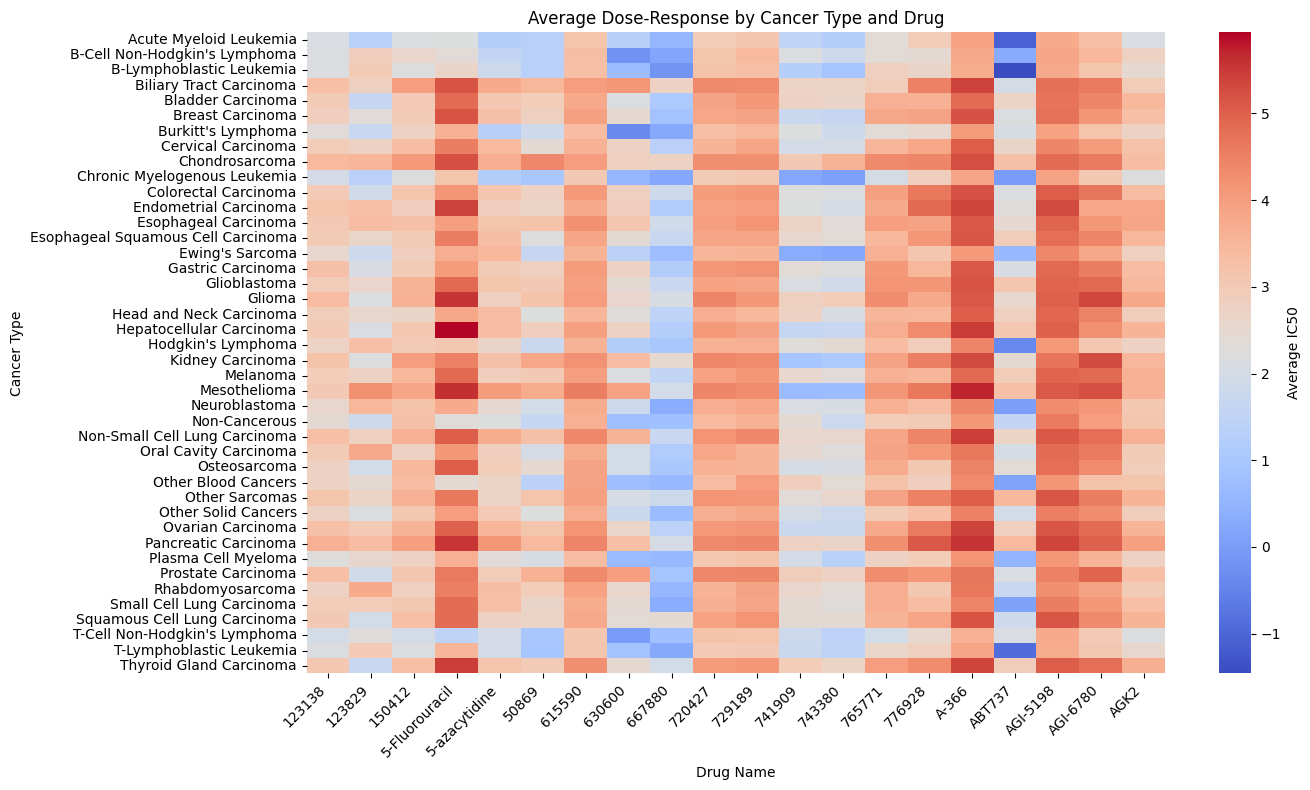

In [10]:
# Heatmap of Cancer Type vs Drug with average dose response
# Assumes there's a column like 'IC50' or similar dose-response metric
heatmap_data = df.pivot_table(values='LN_IC50', index='CANCER_TYPE', columns='DRUG_NAME', aggfunc='mean')

plt.figure(figsize=(14, 8))
sns.heatmap(heatmap_data.iloc[:, :20], cmap='coolwarm', cbar_kws={'label': 'Average IC50'})
plt.xlabel('Drug Name')
plt.ylabel('Cancer Type')
plt.title('Average Dose-Response by Cancer Type and Drug')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

IC_50 is Half Maximal Inhibitory Concentration
- Concentration of the drug that is necessary to stop 50% of the cancer growth
- Logarithm tells us: blue means lower/negative values, so you just need a small drug dosis; red is analog
- for example the drug "ABT737" has many blue boxes, especially in combination with different types of leukemia
- there is also a "non-cancerous" category

### Pathways

In [11]:
print("All pathways:")
pathway_names = df['PATHWAY_NAME'].unique()
for pathway in pathway_names:
    print(f"  - {pathway}")

All pathways:
  - DNA replication
  - Mitosis
  - Other
  - EGFR signaling
  - Apoptosis regulation
  - Chromatin histone acetylation
  - ABL signaling
  - ERK MAPK signaling
  - PI3K/MTOR signaling
  - Genome integrity
  - Other, kinases
  - Protein stability and degradation
  - RTK signaling
  - Cell cycle
  - WNT signaling
  - JNK and p38 signaling
  - p53 pathway
  - Cytoskeleton
  - IGF1R signaling
  - Hormone-related
  - Chromatin histone methylation
  - Metabolism
  - Chromatin other
  - Unclassified


### Z-Score

Z_SCORE ANALYSIS

Summary Statistics:
count    2.420360e+05
mean     7.312962e-10
std      9.993925e-01
min     -8.254501e+00
25%     -6.568485e-01
50%      1.058000e-02
75%      6.560362e-01
max      7.978776e+00
Name: Z_SCORE, dtype: float64

Distribution by Drug:
                       mean  std       min       max  count
DRUG_NAME                                                  
CHIR-99021     5.333333e-08  1.0 -2.834820  2.207374    225
GSK2256098C    2.789400e-08  1.0 -2.969008  3.247915    717
Pictilisib     2.585315e-08  1.0 -3.642957  4.302347    967
AZD5582        2.497162e-08  1.0 -3.579402  2.608372    881
AZD5438        2.370990e-08  1.0 -2.323220  3.887613    717
PF-4708671     2.238806e-08  1.0 -3.570390  3.139934    268
Entospletinib  2.237136e-08  1.0 -3.350541  3.320673    894
GSK2830371A    2.092050e-08  1.0 -3.947121  2.947519    717
THR-101        2.051984e-08  1.0 -3.958271  2.886245    731
729189         1.952580e-08  1.0 -4.169217  3.920063    717


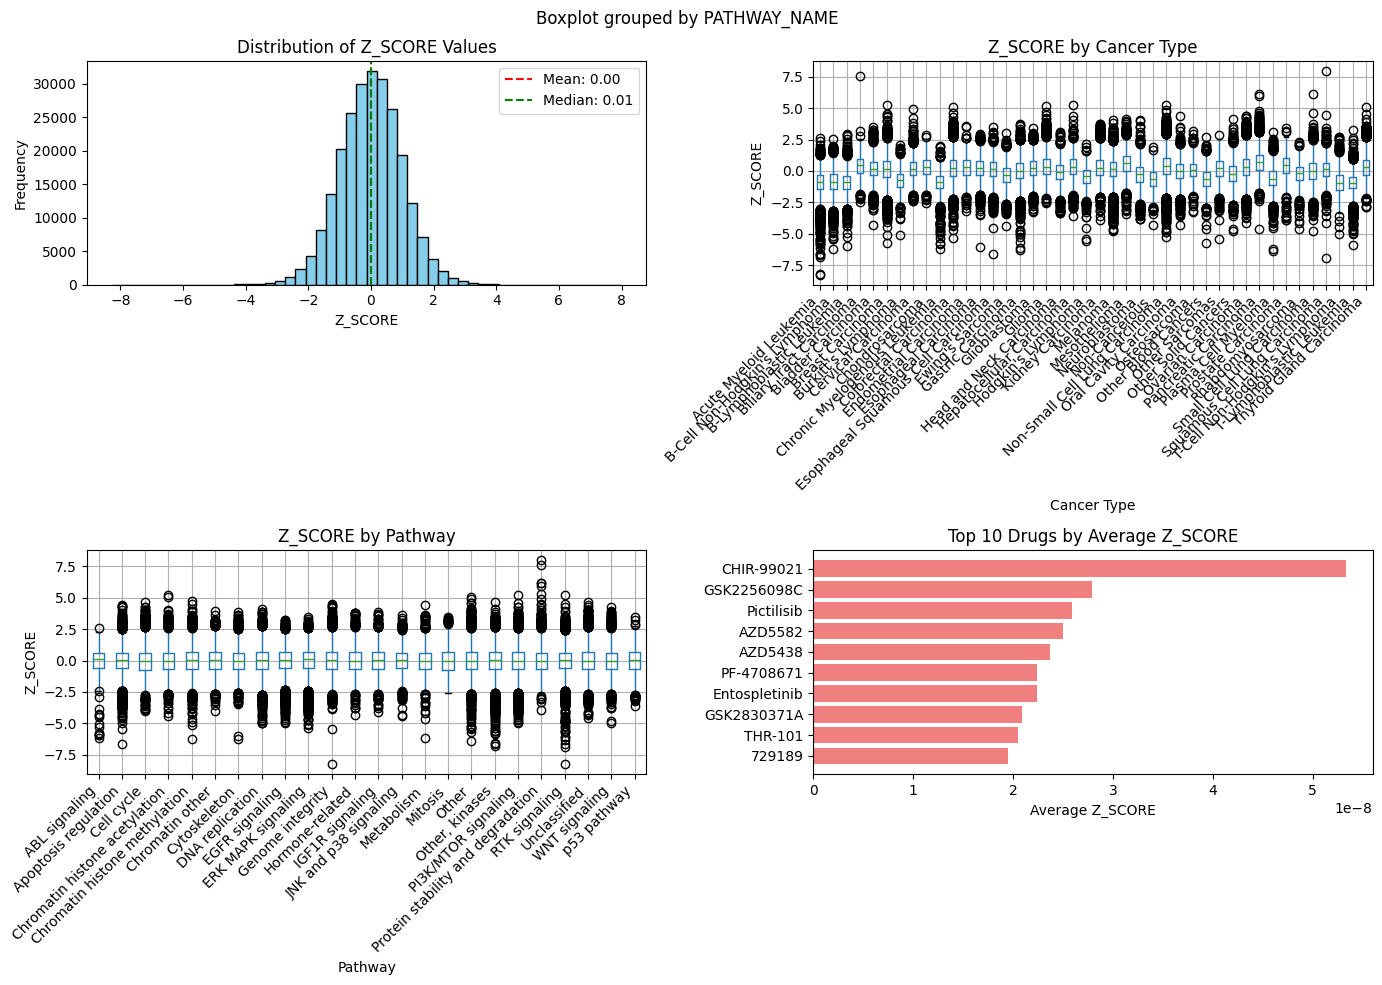

In [12]:
# Z_SCORE Summary Statistics
print("=" * 60)
print("Z_SCORE ANALYSIS")
print("=" * 60)
print("\nSummary Statistics:")
print(df['Z_SCORE'].describe())

print("\n" + "=" * 60)
print("Distribution by Drug:")
print("=" * 60)
drug_z_stats = df.groupby('DRUG_NAME')['Z_SCORE'].agg(['mean', 'std', 'min', 'max', 'count'])
print(drug_z_stats.sort_values('mean', ascending=False).head(10))

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Histogram of Z_SCORE
axes[0, 0].hist(df['Z_SCORE'], bins=50, edgecolor='black', color='skyblue')
axes[0, 0].set_xlabel('Z_SCORE')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of Z_SCORE Values')
axes[0, 0].axvline(df['Z_SCORE'].mean(), color='red', linestyle='--', label=f'Mean: {df["Z_SCORE"].mean():.2f}')
axes[0, 0].axvline(df['Z_SCORE'].median(), color='green', linestyle='--', label=f'Median: {df["Z_SCORE"].median():.2f}')
axes[0, 0].legend()

# 2. Box plot by Cancer Type
df.boxplot(column='Z_SCORE', by='CANCER_TYPE', ax=axes[0, 1])
axes[0, 1].set_title('Z_SCORE by Cancer Type')
axes[0, 1].set_xlabel('Cancer Type')
axes[0, 1].set_ylabel('Z_SCORE')
plt.sca(axes[0, 1])
plt.xticks(rotation=45, ha='right')

# 3. Box plot by Pathway
df.boxplot(column='Z_SCORE', by='PATHWAY_NAME', ax=axes[1, 0])
axes[1, 0].set_title('Z_SCORE by Pathway')
axes[1, 0].set_xlabel('Pathway')
axes[1, 0].set_ylabel('Z_SCORE')
plt.sca(axes[1, 0])
plt.xticks(rotation=45, ha='right')

# 4. Top drugs by average Z_SCORE
top_drugs = df.groupby('DRUG_NAME')['Z_SCORE'].mean().sort_values(ascending=False).head(10)
axes[1, 1].barh(range(len(top_drugs)), top_drugs.values, color='lightcoral')
axes[1, 1].set_yticks(range(len(top_drugs)))
axes[1, 1].set_yticklabels(top_drugs.index)
axes[1, 1].set_xlabel('Average Z_SCORE')
axes[1, 1].set_title('Top 10 Drugs by Average Z_SCORE')
axes[1, 1].invert_yaxis()

plt.tight_layout()
plt.show()

### IC50 value

Missing values: 0
count    242036.000000
mean          2.817079
std           2.762229
min          -8.747724
25%           1.508018
50%           3.236731
75%           4.700110
max          13.820189
Name: LN_IC50, dtype: float64
Skewness: -0.8121474953976449
Kurtosis: 1.0895442455739839


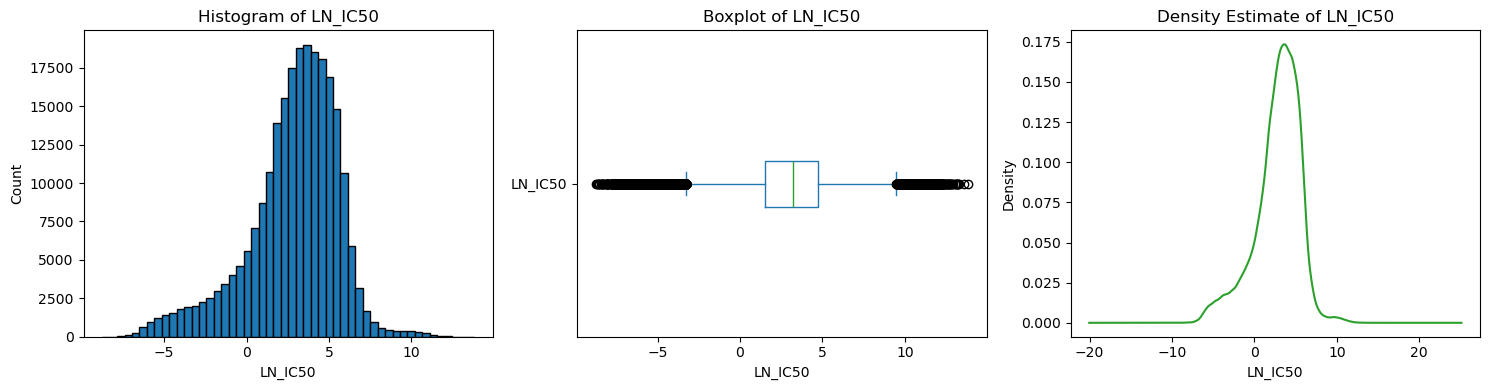

In [37]:
import matplotlib.pyplot as plt

ln_ic50 = df['LN_IC50']

print("Missing values:", ln_ic50.isna().sum())
print(ln_ic50.describe())
print("Skewness:", ln_ic50.skew())
print("Kurtosis:", ln_ic50.kurtosis())

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.hist(ln_ic50.dropna(), bins=50, color='tab:blue', edgecolor='black')
plt.title("Histogram of LN_IC50")
plt.xlabel("LN_IC50")
plt.ylabel("Count")

plt.subplot(1, 3, 2)
ln_ic50.plot(kind='box', vert=False)
plt.title("Boxplot of LN_IC50")
plt.xlabel("LN_IC50")

plt.subplot(1, 3, 3)
ln_ic50.plot(kind='kde', color='tab:green')
plt.title("Density Estimate of LN_IC50")
plt.xlabel("LN_IC50")

plt.tight_layout()
plt.show()

Missing values: 0
count    242036.000000
mean          2.813863
std           2.753079
min          -8.747724
25%           1.508018
50%           3.236731
75%           4.700110
max          10.000000
Name: LN_IC50_clipped, dtype: float64
Skewness: -0.8453758768738973
Kurtosis: 1.030318401657564


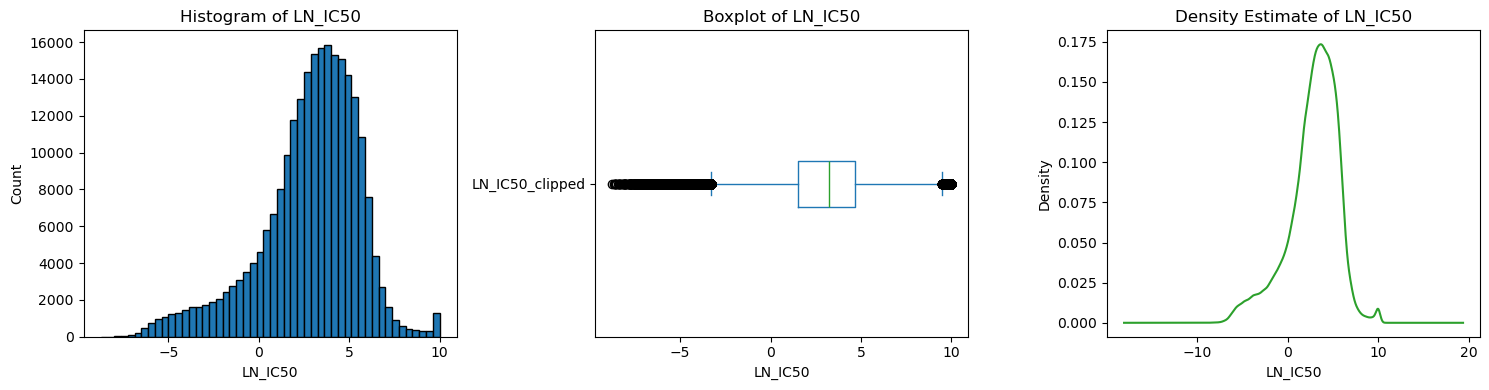

In [39]:
df['LN_IC50_clipped'] = df['LN_IC50'].clip(upper=10)
ln_ic50 = df['LN_IC50_clipped']

print("Missing values:", ln_ic50.isna().sum())
print(ln_ic50.describe())
print("Skewness:", ln_ic50.skew())
print("Kurtosis:", ln_ic50.kurtosis())

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.hist(ln_ic50.dropna(), bins=50, color='tab:blue', edgecolor='black')
plt.title("Histogram of LN_IC50")
plt.xlabel("LN_IC50")
plt.ylabel("Count")

plt.subplot(1, 3, 2)
ln_ic50.plot(kind='box', vert=False)
plt.title("Boxplot of LN_IC50")
plt.xlabel("LN_IC50")

plt.subplot(1, 3, 3)
ln_ic50.plot(kind='kde', color='tab:green')
plt.title("Density Estimate of LN_IC50")
plt.xlabel("LN_IC50")

plt.tight_layout()
plt.show()

Missing values: 0
count    2.420360e+05
mean    -1.202459e-16
std      1.000002e+00
min     -4.199521e+00
25%     -4.743228e-01
50%      1.535985e-01
75%      6.851422e-01
max      2.610224e+00
Name: LN_IC50_clipped, dtype: float64
Skewness: -0.8453758768738967
Kurtosis: 1.030318401657564


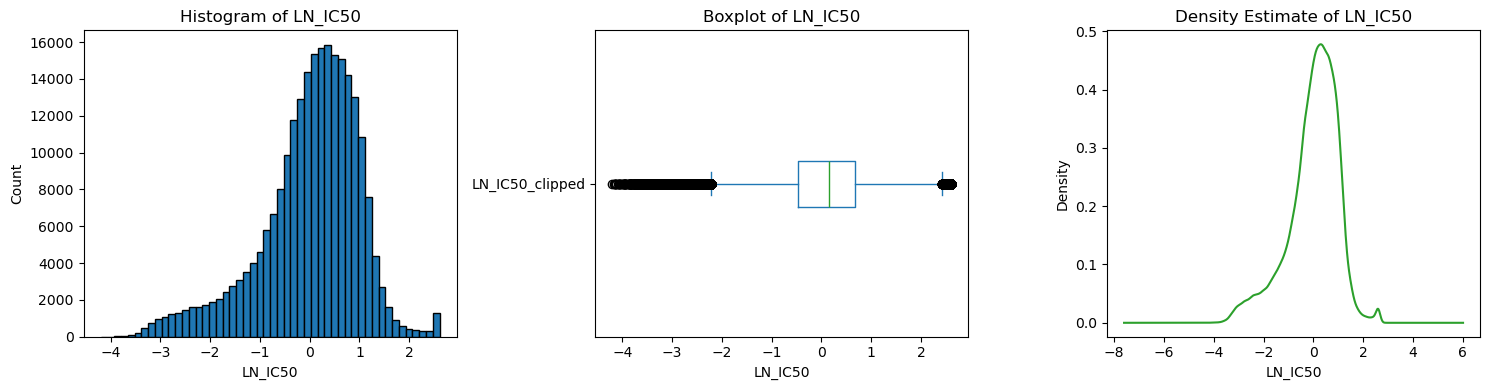

In [43]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(df[['LN_IC50_clipped']])
df['LN_IC50_clipped'] = scaler.transform(df[['LN_IC50_clipped']])
ln_ic50 = df['LN_IC50_clipped']

print("Missing values:", ln_ic50.isna().sum())
print(ln_ic50.describe())
print("Skewness:", ln_ic50.skew())
print("Kurtosis:", ln_ic50.kurtosis())

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.hist(ln_ic50.dropna(), bins=50, color='tab:blue', edgecolor='black')
plt.title("Histogram of LN_IC50")
plt.xlabel("LN_IC50")
plt.ylabel("Count")

plt.subplot(1, 3, 2)
ln_ic50.plot(kind='box', vert=False)
plt.title("Boxplot of LN_IC50")
plt.xlabel("LN_IC50")

plt.subplot(1, 3, 3)
ln_ic50.plot(kind='kde', color='tab:green')
plt.title("Density Estimate of LN_IC50")
plt.xlabel("LN_IC50")

plt.tight_layout()
plt.show()

## Harmonize data

This is a public dataset regarding gene expression.

In [10]:
ge = pd.read_csv(r"C:\Users\Juli\Documents\Master\Projekt Genomforschung\Datasets\OmicsExpressionTPMLogp1HumanProteinCodingGenes.csv", index_col=0)

Metadata describing all cancer models/cell lines which are referenced by a dataset contained within the DepMap portal

In [13]:
metadata = pd.read_csv(r"C:\Users\Juli\Documents\Master\Projekt Genomforschung\Datasets\Model.csv", usecols=['ModelID', 'COSMICID', 'SangerModelID', 'ModelIDAlias'])
metadata.rename(columns={'SangerModelID': 'SANGER_MODEL_ID'}, inplace=True)

In [14]:
metadata.head()

,ModelID,SANGER_MODEL_ID,COSMICID,ModelIDAlias
0,ACH-000001,SIDM00105,905933.0,NaN
1,ACH-000002,SIDM00829,905938.0,NaN
2,ACH-000003,SIDM00891,NaN,NaN
3,ACH-000004,SIDM00594,907053.0,NaN
4,ACH-000005,SIDM00593,NaN,NaN


### L1000 landmark geneset

In [16]:
L1000 = pd.read_csv(r"C:\Users\Juli\Documents\Master\Projekt Genomforschung\Datasets\L1000.txt", sep='\t')

- ID = Entrez Gene ID for the feature
- spot_id = 24nt unique molecular barcode tagged per gene bead
- pr_analyte_id = Full name of the Luminex analyte used to measure the feature
- pr_analyte_num = Integer index of the Luminex analyte used to measure the feature
- pr_bset_id = Set of beads (beadset) that was used to measure this feature (2 beadsets are used to make the duplex measurement, allowing the ~1000 features to be measured using the 500 distinct analytes
- pr_gene_symbol = HUGO gene symbol for the feature
- sequence = 20nt gene-specific fragment

In [17]:
L1000.head()

,ID,spot_id,pr_analyte_id,pr_analyte_num,pr_bset_id,pr_gene_symbol,sequence
0,5720,LUA-3404,Analyte 11,11,dp52,PSME1,ACATCCGGCTGATGGTCATGGAGATCCGCAATGCTTATGC
1,55847,LUA-3431,Analyte 12,12,dp52,CISD1,ACCACCTCTGTCTGATTCACCTTCGCTGGATTCTAAATGT
2,25803,LUA-1326,Analyte 13,13,dp52,SPDEF,CCCCTGAGTTGGGCAGCCAGGAGTGCCCCCGGGAATGGAT
3,466,LUA-3660,Analyte 14,14,dp52,ATF1,TTCAGATTGGCTAATATTTGCATTGTAAATTTTGTATGCA
4,6009,LUA-3487,Analyte 15,15,dp52,RHEB,AGAAAAAATGGACGGGGCAGCTTCACAAGGCAAGTCTTCA


Shrinking the dataset to the L1000 landmark genes

In [18]:
ge_col2id = {}
for col in ge.columns: 
    match = re.search(r"\((\d+)\)\s*$", col) # Extract Entrez IDs from ge column names like "TSPAN6 (7105)"
    if match:
        ge_col2id[col] = int(match.group(1))

# Normalize L1000 IDs to integers and filter
L1000_ids = set(pd.to_numeric(L1000['ID'], errors='coerce').dropna().astype(int))
valid_ge_cols = [col for col, entrez in ge_col2id.items() if entrez in L1000_ids]
# New dataframe containing only matching columns
ge_matched = ge[['SequencingID', 'ModelID', 'IsDefaultEntryForModel', 'ModelConditionID', 'IsDefaultEntryForMC'] + valid_ge_cols].copy()
print(f"Selected {len(valid_ge_cols)} matching columns out of {len(ge.columns)} total ge columns and saving it in ge_matched.")
ge_matched.head()

Selected 978 matching columns out of 19220 total ge columns and saving it in ge_matched.


,SequencingID,ModelID,IsDefaultEntryForModel,ModelConditionID,IsDefaultEntryForMC,TSPAN6 (7105),SCYL3 (57147),BAD (572),LAP3 (51056),SNX11 (29916),...,TWF2 (11344),HOXA10 (3206),LYN (4067),CHMP4A (29082),POLG2 (11232),RBM15B (29890),MRPL12 (6182),IKBKE (9641),DUSP14 (11072),PIP4K2B (8396)
0,CDS-010xbm,ACH-001113,Yes,MC-001113-k2lR,Yes,4.956577,3.179411,5.585888,4.856592,4.772382,...,3.881244,0.000000,3.227964,6.106993,5.376176,3.781716,5.136060,0.109694,5.508574,4.871706
1,CDS-02TzJp,ACH-001289,Yes,MC-001289-BpdI,Yes,4.954992,2.783576,6.156599,6.250399,4.671135,...,4.852119,0.728105,1.672380,6.519867,4.233543,4.201579,5.594133,0.785037,5.485163,4.834484
2,CDS-0693hw,ACH-001339,Yes,MC-001339-5nRN,Yes,3.421952,2.615880,5.096717,6.269129,4.636549,...,5.359300,5.015306,2.780102,5.620372,3.471266,3.439807,6.475904,2.395142,5.904340,4.273322
3,CDS-07Plat,ACH-001619,No,MC-001619-IR6I,No,5.196729,2.144996,5.558329,4.844245,3.838508,...,4.122225,4.336676,3.525104,5.518346,3.973556,3.831816,7.464897,2.988021,5.422105,4.581984
4,CDS-08FOcu,ACH-001979,Yes,MC-001979-E3qW,Yes,4.651643,2.454515,5.053415,7.138825,4.414575,...,4.981935,0.000000,2.447391,6.384074,2.434762,3.957525,4.427103,2.109839,5.237908,4.540963


### Meta categories for cancer type

Creating meta categories for cancer types so that the plots get more understandable


In [14]:
category_map = {
    # Hematologic (Blood & Lymph)
    'T-Lymphoblastic Leukemia': 'Blood/Lymph',
    'Acute Myeloid Leukemia': 'Blood/Lymph',
    'Chronic Myelogenous Leukemia': 'Blood/Lymph',
    'B-Lymphoblastic Leukemia': 'Blood/Lymph',
    'Plasma Cell Myeloma': 'Blood/Lymph',
    "T-Cell Non-Hodgkin's Lymphoma": 'Blood/Lymph',
    "B-Cell Non-Hodgkin's Lymphoma": 'Blood/Lymph',
    "Burkitt's Lymphoma": 'Blood/Lymph',
    "Hodgkin's Lymphoma": 'Blood/Lymph',
    'Other Blood Cancers': 'Blood/Lymph',

    # Gastrointestinal (GI Tract)
    'Colorectal Carcinoma': 'Gastrointestinal',
    'Gastric Carcinoma': 'Gastrointestinal',
    'Pancreatic Carcinoma': 'Gastrointestinal',
    'Hepatocellular Carcinoma': 'Gastrointestinal',
    'Biliary Tract Carcinoma': 'Gastrointestinal',
    'Esophageal Carcinoma': 'Gastrointestinal',
    'Esophageal Squamous Cell Carcinoma': 'Gastrointestinal',

    # Thoracic (Lung & Chest)
    'Non-Small Cell Lung Carcinoma': 'Thoracic',
    'Squamous Cell Lung Carcinoma': 'Thoracic',
    'Small Cell Lung Carcinoma': 'Thoracic',
    'Mesothelioma': 'Thoracic',

    # Sarcomas (Bone & Soft Tissue)
    "Ewing's Sarcoma": 'Sarcoma/Bone',
    'Osteosarcoma': 'Sarcoma/Bone',
    'Chondrosarcoma': 'Sarcoma/Bone',
    'Rhabdomyosarcoma': 'Sarcoma/Bone',
    'Other Sarcomas': 'Sarcoma/Bone',

    # CNS (Brain)
    'Glioblastoma': 'CNS',
    'Glioma': 'CNS',
    'Neuroblastoma': 'CNS', # Oft PNS, aber meist mit ZNS gruppiert

    # Gynecologic / Urologic
    'Ovarian Carcinoma': 'Uro/Gyn',
    'Cervical Carcinoma': 'Uro/Gyn',
    'Endometrial Carcinoma': 'Uro/Gyn',
    'Breast Carcinoma': 'Uro/Gyn',
    'Prostate Carcinoma': 'Uro/Gyn',
    'Bladder Carcinoma': 'Uro/Gyn',
    'Kidney Carcinoma': 'Uro/Gyn',

    # Head & Neck / Skin / Endocrine
    'Melanoma': 'Skin/HNSC',
    'Head and Neck Carcinoma': 'Skin/HNSC',
    'Oral Cavity Carcinoma': 'Skin/HNSC',
    'Thyroid Gland Carcinoma': 'Skin/HNSC',

    # Others
    'Non-Cancerous': 'Control',
    'Other Solid Cancers': 'Other'
}
# Anwendung auf den DataFrame
#df['META_CANCERTYPE'] = df['CANCER_TYPE'].map(category_map).fillna('Other')
ge_matched['META_CANCERTYPE'] = ge_matched['CANCER_TYPE'].map(category_map).fillna('Other')

### Big merge with complete drug data

First I add Sanger Model ID to gene expression data. Then the cancer type information, the Sanger Model ID serves as bridge.

In [20]:
# delete columns that we don't use
ge_matched = ge_matched.drop(columns=['IsDefaultEntryForModel', 'ModelConditionID', 'IsDefaultEntryForMC'])
# filter for non-null SANGER_MODEL_ID and select only necessary columns for the merge
mapping_bridge = metadata[['ModelID', 'SANGER_MODEL_ID']].dropna(subset=['SANGER_MODEL_ID'])

# merge with left join to keep all rows in ge_matched and add SANGER_MODEL_ID where available
if 'SANGER_MODEL_ID' in ge_matched.columns:
    ge_matched = ge_matched.drop(columns=['SANGER_MODEL_ID'])
ge_matched = pd.merge(ge_matched, mapping_bridge, on='ModelID', how='left')

# include cancer type information by merging with the original dataframe
cancer_info = df[['SANGER_MODEL_ID', 'CANCER_TYPE']].drop_duplicates()
ge_matched = pd.merge(ge_matched, cancer_info, on='SANGER_MODEL_ID', how='left')
if 'CANCER_TYPE' in ge_matched.columns:
    ge_matched['CANCER_TYPE'] = ge_matched['CANCER_TYPE'].fillna('Unknown')
    print("CANCER_TYPE was added successfully.")
else:
    ge_matched['CANCER_TYPE'] = 'Unknown'
    print("No matches found; CANCER_TYPE set to 'Unknown'.")

CANCER_TYPE was added successfully.


In [21]:
# Count NaN values in SANGER_MODEL_ID
nan_count = ge_matched['SANGER_MODEL_ID'].isna().sum()
print(f"Number of NaN values in ge_matched.SANGER_MODEL_ID: {nan_count}, so {nan_count/ge_matched.shape[0]:.2%} of the rows have NaN SANGER_MODEL_ID.")

Number of NaN values in ge_matched.SANGER_MODEL_ID: 840, so 47.89% of the rows have NaN SANGER_MODEL_ID.


Create a master df which contains the merged dataframes

In [22]:
# Selection of relevant columns from drug dataframe (df): need id to merge + target values (labels)
drug_data_cols = [
    'SANGER_MODEL_ID', 'DRUG_ID', 'DRUG_NAME', 
    'LN_IC50', 'Z_SCORE', 'RMSE', 'AUC'
]
df_subset = df[drug_data_cols]

# merge, only keep rows where we have both gene expression data AND drug response data
master_df = pd.merge(ge_matched, df_subset, on='SANGER_MODEL_ID', how='inner')

# check results
print(f"Dimension of the new master df: {master_df.shape}")
print(f"Unique drugs: {master_df['DRUG_NAME'].nunique()}")
print(f"Unique cell lines: {master_df['SANGER_MODEL_ID'].nunique()}")

Dimension of the new master df: (186550, 988)
Unique drugs: 286
Unique cell lines: 715


In [25]:
master_df.head()

,SequencingID,ModelID,TSPAN6 (7105),SCYL3 (57147),BAD (572),LAP3 (51056),SNX11 (29916),CASP10 (843),CFLAR (8837),FKBP4 (2288),...,DUSP14 (11072),PIP4K2B (8396),SANGER_MODEL_ID,CANCER_TYPE,DRUG_ID,DRUG_NAME,LN_IC50,Z_SCORE,RMSE,AUC
0,CDS-0CqPRM,ACH-000242,7.10594,2.700053,5.803904,5.66261,4.231824,2.283468,4.735717,6.484923,...,3.837408,4.235061,SIDM01085,Bladder Carcinoma,1003,Camptothecin,-2.963191,-0.383200,0.094466,0.821438
1,CDS-0CqPRM,ACH-000242,7.10594,2.700053,5.803904,5.66261,4.231824,2.283468,4.735717,6.484923,...,3.837408,4.235061,SIDM01085,Bladder Carcinoma,1004,Vinblastine,-4.023106,-0.244142,0.122361,0.712813
2,CDS-0CqPRM,ACH-000242,7.10594,2.700053,5.803904,5.66261,4.231824,2.283468,4.735717,6.484923,...,3.837408,4.235061,SIDM01085,Bladder Carcinoma,1005,Cisplatin,2.848175,-0.203192,0.108946,0.938878
3,CDS-0CqPRM,ACH-000242,7.10594,2.700053,5.803904,5.66261,4.231824,2.283468,4.735717,6.484923,...,3.837408,4.235061,SIDM01085,Bladder Carcinoma,1006,Cytarabine,2.218343,0.292158,0.117640,0.953169
4,CDS-0CqPRM,ACH-000242,7.10594,2.700053,5.803904,5.66261,4.231824,2.283468,4.735717,6.484923,...,3.837408,4.235061,SIDM01085,Bladder Carcinoma,1007,Docetaxel,-4.240700,0.074531,0.070175,0.884847


## Adding chemical features

### Get SMILES codes for each drug

In [27]:
import pubchempy as pcp

Be careful, sometimes the pubchem server is overloaded!

In [28]:
# Extract only the unique DRUG_IDs to minimize API calls
unique_drugs_df = master_df[['DRUG_ID']].drop_duplicates().dropna()

# Define the function to fetch SMILES via PubChem CID
def fetch_smiles_by_cid(drug_id):
    try:
        # Clean the ID (ensure it is an integer, handle floats like 2244.0)
        clean_cid = int(drug_id)
        
        # Add a small delay to respect PubChem API rate limits (5 requests/sec)
        time.sleep(0.2) 
        
        # Fetch the compound and return the canonical SMILES
        compound = pcp.get_compounds(clean_cid, namespace='cid')[0]
        return compound.connectivity_smiles
        
    except Exception as e:
        # Print the exact ID that failed for easier debugging later
        print(f"Failed to fetch SMILES for CID {drug_id}. Reason: {e}")
        return None

# Apply the function ONLY to the unique IDs (e.g., your 238 unique IDs)
print(f"Fetching SMILES for {len(unique_drugs_df)} unique drugs from PubChem...")
unique_drugs_df['SMILES'] = unique_drugs_df['DRUG_ID'].apply(fetch_smiles_by_cid)

# Merge the new SMILES column back into the large master dataframe
print("Merging SMILES back into the main dataframe...")
master_df = master_df.merge(unique_drugs_df, on='DRUG_ID', how='left')

# Check result
missing_smiles = master_df['SMILES'].isna().sum()
print(f"Process complete. Rows with missing SMILES: {missing_smiles}")

Fetching SMILES for 295 unique drugs from PubChem...
Failed to fetch SMILES for CID 1008. Reason: PubChem HTTP Error 502 Bad Gateway
Failed to fetch SMILES for CID 1024. Reason: PubChem HTTP Error 502 Bad Gateway
Failed to fetch SMILES for CID 1428. Reason: PubChem HTTP Error 502 Bad Gateway
Failed to fetch SMILES for CID 1739. Reason: PubChem HTTP Error 502 Bad Gateway
Merging SMILES back into the main dataframe...
Process complete. Rows with missing SMILES: 2537


### Add Morgan fingerprints and pharmacophore features.

In [29]:
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import ChemicalFeatures
from rdkit import RDConfig
import os

Functions for 1. get Morgan Fingerprints as array and 2. get pharmacophore features as dictionary

In [30]:
def get_mfp(smiles):
    """
    Takes a SMILES string and returns a numpy array of the Morgan fingerprint (1024 bits).
    """
    try:
        morganfp = AllChem.GetMorganFingerprintAsBitVect(Chem.MolFromSmiles(smiles),
                                                         radius=2, nBits=1024)
        return np.array(morganfp)
    except:
        return None

# initialise the "feature factory"
# RDKIT provides a standard file (BaseFeatures.fdef) that defines what exactly a H-donor, acceptor, etc. is.
fdef_name = os.path.join(RDConfig.RDDataDir, 'BaseFeatures.fdef')
factory = ChemicalFeatures.BuildFeatureFactory(fdef_name) # is a MolChemicalFeatureFactory object

def get_pharmacophore_features(smiles):
    """
    Takes a SMILES string and returns a dictionary containing the number of chemical features found (e.g., {‘Donor’: 2, ‘Acceptor’: 4}).
    """
    if pd.isna(smiles):
        return {}
    
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return {}
        
    # extract all features for the molecule
    features = factory.GetFeaturesForMol(mol)
    
    # count how many times each feature family appears
    feature_counts = {}
    for feat in features:
        family = feat.GetFamily()
        feature_counts[family] = feature_counts.get(family, 0) + 1
            
    return feature_counts


Function to get Morgan fingerprints in separate columns

In [31]:
def smiles_to_morgan_columns(df, smiles_col='SMILES', n_bits=1024, radius=2):
    # Calculates 1024-bit Morgan Fingerprints and expands them into individual columns.
    mols = [Chem.MolFromSmiles(s) if pd.notna(s) else None for s in df[smiles_col]]

    fingerprints = []
    for mol in mols:
        if mol:
            # Generate the bit vector
            bv = AllChem.GetMorganFingerprintAsBitVect(mol, radius=radius, nBits=n_bits)
            # Convert to list of 0s and 1s
            fingerprints.append(list(bv))
        else:
            # Maintain row alignment with a list of zeros if SMILES was invalid
            fingerprints.append([0] * n_bits)

    # Create new DataFrame from the list of lists
    fp_df = pd.DataFrame(fingerprints, index=df.index)

    # Rename columns to 'Bit_0', 'Bit_1', etc.
    fp_df.columns = [f'Bit_{i}' for i in range(n_bits)]
    fp_df = fp_df.astype('uint8')

    # Concatenate with the original DataFrame
    result_df = pd.concat([df, fp_df], axis=1)
    print("Fingerprints expanded into columns.")
    return result_df

Apply wanted function

In [ ]:
#master_df = smiles_to_morgan_columns(master_df, smiles_col='SMILES')
master_df['MorganFP'] = master_df['SMILES'].apply(get_mfp)
master_df['PharmacophoreFeatures'] = master_df['SMILES'].apply(get_pharmacophore_features)

### Remove duplicate drugs

Some drugs are duplicated under a different name. If Model ID and SMILES are the same, we assume it's the same drug-cell line combination and can be averaged.


In [34]:
print(f"Number of rows with NaN SMILES: {master_df['SMILES'].isna().sum()}, gonna remove them")
master_df.dropna(subset=['SMILES'], inplace=True) # removes 33221 rows

Number of rows with NaN SMILES: 0, gonna remove them


In [35]:
print(f"Number of rows before aggregation: {len(master_df)}")
# create a dictionary that contains all columns
agg_dict = {col: 'first' for col in master_df.columns}
target_metrics = ['LN_IC50', 'AUC', 'Z_SCORE', 'RMSE']
for metric in target_metrics:
    if metric in agg_dict:
        agg_dict[metric] = 'mean'
group_cols = ['ModelID', 'SMILES']
for col in group_cols:
    if col in agg_dict:
        del agg_dict[col]
# grouping; it Model ID and SMILES are the same, we assume it's the same drug-cell line combination and can be averaged
master_df = master_df.groupby(group_cols, as_index=False).agg(agg_dict)
print(f"Number of rows after aggregation: {len(master_df)}")

Number of rows before aggregation: 178818


C:\Users\Juli\AppData\Local\Temp\ipykernel_29012\2342813583.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  master_df = master_df.groupby(group_cols, as_index=False).agg(agg_dict)
C:\Users\Juli\AppData\Local\Temp\ipykernel_29012\2342813583.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  master_df = master_df.groupby(group_cols, as_index=False).agg(agg_dict)


Number of rows after aggregation: 178818


## Save as Pickle file

In [36]:
# save
#master_df.to_pickle("harmonized_data.pkl")
# load
#master_df = pd.read_pickle("harmonized_data.pkl")